# 15 - Multi-Model Ensemble Experiment (BiLSTM + BiGRU + 4-Block Transformer)
## Tai Phake Visual Speech Recognition (VSR) Project

### Experiment Objective: Tri-Model Late Fusion / Probability Averaging
In our speaker-independent 80/20 benchmark (24 base train speakers / 6 base validation speakers), three diverse temporal architectures were trained using an identical ImageNet-pretrained **EfficientNetB0** visual backbone:
1. **EfficientNetB0 + BiLSTM + Learnable Attention Pooling** (~60.5% validation accuracy)
2. **EfficientNetB0 + BiGRU + Learnable Attention Pooling** (~60.0% validation accuracy)
3. **EfficientNetB0 + 4-Block Transformer** (~52.7% validation accuracy)

**Key Hypothesis & Motivation:**
- **Complementary Error Distributions**: Because recurrent models (BiLSTM/BiGRU) with sequence inductive bias and self-attention models (Transformer) model temporal dependencies through distinct mathematical mechanisms, they commit non-overlapping errors on specific digits:
  - BiLSTM achieves higher recall on subtle lip closures like $d_7$.
  - BiGRU resolves rapid transitions like $d_2$ more accurately.
  - Transformer captures global temporal co-articulation on classes like $d_{10}$.
- **Ensemble Formulation**: By loading the best Stage 2 fine-tuned checkpoint weights for all three champions and performing **soft voting (probability averaging)** across predicted class probability vectors:
  $$\mathbf{P}_{\text{ensemble}} = w_{\text{lstm}}\mathbf{P}_{\text{lstm}} + w_{\text{gru}}\mathbf{P}_{\text{gru}} + w_{\text{trans}}\mathbf{P}_{\text{trans}}$$
  we evaluate both **uniform averaging** ($w_i = 1/3$) and **optimal weighted averaging via grid search**.


## 1. Experiment Mode & Seed Setup

In [1]:
# Section 1: Experiment Configuration
DATASET_MODE = "80_20"
SEED = 42


## 2. Imports

In [2]:
# Section 2: Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import sklearn.metrics as metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
import keras

print("=" * 80)
print("ENVIRONMENT & DEPENDENCY VERSIONS")
print("=" * 80)
print(f"Python Version:     {sys.version.split()[0]}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
print(f"Available GPUs:     {len(gpu_devices)} ({gpu_devices})")
print("=" * 80)


ENVIRONMENT & DEPENDENCY VERSIONS
Python Version:     3.12.13
TensorFlow Version: 2.21.0
Keras Version:      3.15.1
Available GPUs:     0 ([])


## 3. Configuration & Classes

In [3]:
# Section 3: Configuration & Hyperparameters
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Sequence & Image Specifications (Method D standard)
NUM_CLASSES = 11
NUM_FRAMES = 30
FRAME_WIDTH = 96
FRAME_HEIGHT = 96
FRAME_CHANNELS = 3
BATCH_SIZE = 16

# Architecture Dimensions
PROJECTION_DIM = 256
LSTM_UNITS = 128
GRU_UNITS = 128
EMBED_DIM = 256
NUM_HEADS = 4
KEY_DIM = 64
FFN_DIM = 512
NUM_TRANSFORMER_BLOCKS = 4

# Target Digit Classes (d0 through d10)
DIGIT_CLASSES = [f"d{i}" for i in range(NUM_CLASSES)]
CLASS_TO_ID = {d: i for i, d in enumerate(DIGIT_CLASSES)}
ID_TO_CLASS = {i: d for i, d in enumerate(DIGIT_CLASSES)}

print("=" * 80)
print("ENSEMBLE EVALUATION SETUP")
print("=" * 80)
print(f"Dataset Mode         : {DATASET_MODE}")
print(f"Target Digit Classes : {DIGIT_CLASSES}")
print(f"Input Sequence Shape : ({NUM_FRAMES}, {FRAME_HEIGHT}x{FRAME_WIDTH}, {FRAME_CHANNELS})")
print("=" * 80)


ENSEMBLE EVALUATION SETUP
Dataset Mode         : 80_20
Target Digit Classes : ['d0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10']
Input Sequence Shape : (30, 96x96, 3)


## 4. Dataset & Checkpoint Paths

In [4]:
# Section 4: Dataset Paths Configuration & Model Checkpoint Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

# Dedicated Results Directory for Ensemble
RESULTS_DIR = PROJECT_ROOT / "results" / f"ensemble_bilstm_bigru_transformer_{DATASET_MODE}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint weight paths from prior experiments
WEIGHTS_LSTM_PATH = PROJECT_ROOT / "results" / f"efficientnetb0_bilstm_attention_pooling_{DATASET_MODE}" / "efficientnetb0_bilstm_attention_pooling_stage2_best.weights.h5"
WEIGHTS_GRU_PATH = PROJECT_ROOT / "results" / f"efficientnetb0_bigru_attention_pooling_{DATASET_MODE}" / "efficientnetb0_bigru_attention_pooling_stage2_best.weights.h5"
WEIGHTS_TRANS_PATH = PROJECT_ROOT / "results" / f"efficientnetb0_transformer_4block_{DATASET_MODE}" / "efficientnetb0_transformer_4block_stage2_best.weights.h5"

print("Checkpoint weight availability check:")
print(f"  BiLSTM Weights      : {WEIGHTS_LSTM_PATH.exists()} ({WEIGHTS_LSTM_PATH})")
print(f"  BiGRU Weights       : {WEIGHTS_GRU_PATH.exists()} ({WEIGHTS_GRU_PATH})")
print(f"  Transformer Weights : {WEIGHTS_TRANS_PATH.exists()} ({WEIGHTS_TRANS_PATH})")
print(f"  Output Results Dir  : {RESULTS_DIR}")


Checkpoint weight availability check:
  BiLSTM Weights      : True (/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_bilstm_attention_pooling_80_20/efficientnetb0_bilstm_attention_pooling_stage2_best.weights.h5)
  BiGRU Weights       : True (/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_bigru_attention_pooling_80_20/efficientnetb0_bigru_attention_pooling_stage2_best.weights.h5)
  Transformer Weights : True (/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/efficientnetb0_transformer_4block_stage2_best.weights.h5)
  Output Results Dir  : /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/ensemble_bilstm_bigru_transformer_80_20


## 5. Speaker Split Verification

In [5]:
# Section 5: Speaker Split Verification & Diagnostics
train_speakers = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])
val_speakers = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])

def get_base_speaker(spk_name: str) -> str:
    return spk_name.split("_")[0]

base_train_speakers = sorted(list(set(get_base_speaker(s) for s in train_speakers)))
base_val_speakers = sorted(list(set(get_base_speaker(s) for s in val_speakers)))

print("=" * 80)
print("SPEAKER SPLIT VERIFICATION")
print("=" * 80)
print(f"Train Directory ({len(train_speakers)} folders) -> {len(base_train_speakers)} Base Speakers: {base_train_speakers}")
print(f"Val Directory   ({len(val_speakers)} folders) -> {len(base_val_speakers)} Base Speakers: {base_val_speakers}")
overlap = set(base_train_speakers).intersection(set(base_val_speakers))
assert len(overlap) == 0, f"DATA LEAKAGE DETECTED! Overlap: {overlap}"
print("[OK] Zero speaker leakage between train and validation splits!")
print("=" * 80)


SPEAKER SPLIT VERIFICATION
Train Directory (80 folders) -> 24 Base Speakers: ['s1', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's2', 's20', 's21', 's22', 's23', 's24', 's3', 's4', 's5', 's6', 's7', 's8', 's9']
Val Directory   (20 folders) -> 6 Base Speakers: ['s25', 's26', 's27', 's28', 's29', 's30']
[OK] Zero speaker leakage between train and validation splits!


## 6. Manifest Creation

In [6]:
# Section 6: Manifest Creation
def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else str(p)

manifest_records = []

splits = [("train", TRAIN_DIR), ("val", VAL_DIR)]
if DATASET_MODE == "100_3_3" and TEST_DIR.exists():
    splits.append(("test", TEST_DIR))

for split_name, split_path in splits:
    for spk_dir in sorted(split_path.iterdir()):
        if not spk_dir.is_dir() or spk_dir.name.startswith("."):
            continue
        for digit_dir in sorted(spk_dir.iterdir()):
            if not digit_dir.is_dir() or digit_dir.name.startswith("."):
                continue
            digit_name = digit_dir.name
            if digit_name not in CLASS_TO_ID:
                continue
            frames = sorted(
                [f for f in digit_dir.iterdir() if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]],
                key=natural_sort_key
            )
            if len(frames) == 0:
                continue
            manifest_records.append({
                "split": split_name,
                "speaker": spk_dir.name,
                "base_speaker": get_base_speaker(spk_dir.name),
                "digit": digit_name,
                "digit_id": CLASS_TO_ID[digit_name],
                "frame_count": len(frames),
                "frame_paths": [str(f) for f in frames]
            })

df_manifest = pd.DataFrame(manifest_records)
print(f"Manifest created with {len(df_manifest):,} total video utterances across splits:")
print(df_manifest["split"].value_counts().to_string())


Manifest created with 1,100 total video utterances across splits:
split
train    880
val      220


## 7. Frame Sampling & In-Memory Loading

In [7]:
# Section 7: Frame Sampling & In-Memory Sequence Loading
def sample_30_frames(frame_paths: list, target_frames: int = NUM_FRAMES) -> list:
    """
    Deterministic temporal sampling across the video duration.
    Produces exactly target_frames (30) uniformly distributed frame indices.
    """
    n = len(frame_paths)
    if n == target_frames:
        indices = list(range(target_frames))
    else:
        indices = np.round(np.linspace(0, n - 1, target_frames)).astype(int)
    return [str(frame_paths[i]) for i in indices]

# EXPERIMENT 1 IMPLEMENTATION: dropping 3 frames
# def sample_30_frames(frame_paths: list, target_frames: int = NUM_FRAMES, drop_start: int = 3, drop_end: int = 3) -> list:
#     n = len(frame_paths)
#     # Drop first 3 and last 3 frames (neutral / closed lips)
#     if n > (drop_start + drop_end):
#         trimmed = frame_paths[drop_start:-drop_end]
#     else:
#         trimmed = frame_paths
#
#     n_trimmed = len(trimmed)
#     if n_trimmed == target_frames:
#         indices = list(range(target_frames))
#     else:
#         indices = np.round(np.linspace(0, n_trimmed - 1, target_frames)).astype(int)
#     return [str(trimmed[i]) for i in indices]

df_manifest["sampled_frame_paths"] = df_manifest["frame_paths".split()[-1]].apply(sample_30_frames)
# Correct column lookup
df_manifest["sampled_frame_paths"] = df_manifest["frame_paths"].apply(sample_30_frames)
print(f"Standardized all {len(df_manifest):,} utterances to exactly {NUM_FRAMES} frames.")

def load_all_video_sequences():
    """
    Loads all sampled frames into contiguous NumPy tensors.
    """
    X_data = np.zeros(
        (len(df_manifest), NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        dtype=np.float32
    )
    y_data = np.array(df_manifest["digit_id"].values, dtype=np.int32)

    t0 = time.time()
    for i, row in df_manifest.iterrows():
        for t, fpath in enumerate(row["sampled_frame_paths"]):
            img = Image.open(fpath).convert("RGB")
            if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
                img = img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.BILINEAR)
            X_data[i, t] = np.array(img, dtype=np.float32)

    elapsed = time.time() - t0
    return X_data, y_data, elapsed

print("Loading video sequence tensors into memory...")
X_all, y_all, load_elapsed = load_all_video_sequences()

val_mask = (df_manifest["split"] == "val").values
X_val, y_val = X_all[val_mask], y_all[val_mask]
val_manifest = df_manifest[val_mask].copy().reset_index(drop=True)

print(f"Loaded validation tensor: shape {X_val.shape}, labels: {y_val.shape} in {load_elapsed:.2f}s")


Standardized all 1,100 utterances to exactly 30 frames.
Loading video sequence tensors into memory...
Loaded validation tensor: shape (220, 30, 96, 96, 3), labels: (220,) in 4.78s


## 8. Architecture Builder 1: EfficientNetB0 + BiLSTM + Attention Pooling

In [8]:
# Section 8: Model 1 Builder (BiLSTM + Attention Pooling)
def get_efficientnetb0_backbone():
    cnn = keras.applications.EfficientNetB0(
        input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    preprocess_fn = keras.applications.efficientnet.preprocess_input
    return cnn, preprocess_fn

def build_model_bilstm():
    cnn, preprocess_fn = get_efficientnetb0_backbone()
    inputs = keras.layers.Input(
        shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        name="lip_sequence_input"
    )
    x = keras.layers.TimeDistributed(keras.layers.Lambda(preprocess_fn), name="efficientnetb0_preprocess")(inputs)
    x = keras.layers.TimeDistributed(cnn, name="efficientnetb0_cnn")(x)
    x = keras.layers.TimeDistributed(keras.layers.Dense(PROJECTION_DIM, use_bias=False), name="projection_dense")(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6, name="projection_ln")(x)
    x = keras.layers.Bidirectional(keras.layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=0.2), name="bilstm")(x)

    attn_scores = keras.layers.Dense(1, use_bias=True, name="temporal_attn_score")(x)
    attn_weights = keras.layers.Softmax(axis=1, name="temporal_attn_weights")(attn_scores)
    x = keras.layers.Lambda(lambda tensors: tf.reduce_sum(tensors[0] * tensors[1], axis=1), name="temporal_attention_pooling")([x, attn_weights])

    x = keras.layers.Dropout(0.4, name="head_dropout")(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_BiLSTM_AttentionPooling")

model_lstm = build_model_bilstm()
model_lstm.load_weights(WEIGHTS_LSTM_PATH)
print("[OK] Model 1 (BiLSTM + Attention Pooling) loaded successfully.")


[OK] Model 1 (BiLSTM + Attention Pooling) loaded successfully.


## 9. Architecture Builder 2: EfficientNetB0 + BiGRU + Attention Pooling

In [9]:
# Section 9: Model 2 Builder (BiGRU + Attention Pooling)
def build_model_bigru():
    cnn, preprocess_fn = get_efficientnetb0_backbone()
    inputs = keras.layers.Input(
        shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        name="lip_sequence_input"
    )
    x = keras.layers.TimeDistributed(keras.layers.Lambda(preprocess_fn), name="efficientnetb0_preprocess")(inputs)
    x = keras.layers.TimeDistributed(cnn, name="efficientnetb0_cnn")(x)
    x = keras.layers.TimeDistributed(keras.layers.Dense(PROJECTION_DIM, use_bias=False), name="projection_dense")(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6, name="projection_ln")(x)
    x = keras.layers.Bidirectional(keras.layers.GRU(GRU_UNITS, return_sequences=True, dropout=0.2), name="bigru")(x)

    attn_scores = keras.layers.Dense(1, use_bias=True, name="temporal_attn_score")(x)
    attn_weights = keras.layers.Softmax(axis=1, name="temporal_attn_weights")(attn_scores)
    x = keras.layers.Lambda(lambda tensors: tf.reduce_sum(tensors[0] * tensors[1], axis=1), name="temporal_attention_pooling")([x, attn_weights])

    x = keras.layers.Dropout(0.4, name="head_dropout")(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_BiGRU_AttentionPooling")

model_gru = build_model_bigru()
model_gru.load_weights(WEIGHTS_GRU_PATH)
print("[OK] Model 2 (BiGRU + Attention Pooling) loaded successfully.")


[OK] Model 2 (BiGRU + Attention Pooling) loaded successfully.


## 10. Architecture Builder 3: EfficientNetB0 + 4-Block Transformer

In [10]:
# Section 10: Model 3 Builder (4-Block Transformer)
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, seq_len: int = NUM_FRAMES, dim: int = EMBED_DIM, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.dim = dim
        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(dim)[np.newaxis, :]
        angles = pos / np.power(10000.0, (2 * (i // 2)) / np.float32(dim))
        pe = np.zeros((1, seq_len, dim), dtype=np.float32)
        pe[0, :, 0::2] = np.sin(angles[:, 0::2])
        pe[0, :, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pe

    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.seq_len, "dim": self.dim})
        return config

def transformer_encoder_block(x, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, key_dim=KEY_DIM, ffn_dim=FFN_DIM, dropout=0.2, block_id=1):
    norm1 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm1")(x)
    attn = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name=f"transformer_{block_id}_mha")(norm1, norm1)
    attn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_attn_drop")(attn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add1")([x, attn])

    norm2 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm2")(x)
    ffn = keras.layers.Dense(ffn_dim, activation="gelu", name=f"transformer_{block_id}_ffn1")(norm2)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop1")(ffn)
    ffn = keras.layers.Dense(embed_dim, name=f"transformer_{block_id}_ffn2")(ffn)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop2")(ffn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add2")([x, ffn])
    return x

def build_model_transformer():
    cnn, preprocess_fn = get_efficientnetb0_backbone()
    inputs = keras.layers.Input(
        shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        name="lip_sequence_input"
    )
    x = keras.layers.TimeDistributed(keras.layers.Lambda(preprocess_fn), name="efficientnetb0_preprocess")(inputs)
    x = keras.layers.TimeDistributed(cnn, name="efficientnetb0_cnn")(x)
    x = keras.layers.TimeDistributed(keras.layers.Dense(EMBED_DIM, use_bias=False), name="projection_dense")(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6, name="projection_ln")(x)
    x = PositionalEncoding(seq_len=NUM_FRAMES, dim=EMBED_DIM, name="positional_encoding")(x)
    for b_id in range(1, NUM_TRANSFORMER_BLOCKS + 1):
        x = transformer_encoder_block(x, block_id=b_id)
    x = keras.layers.GlobalAveragePooling1D(name="gap1d")(x)
    x = keras.layers.Dropout(0.4, name="head_dropout")(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_Transformer_4Block")

model_trans = build_model_transformer()
model_trans.load_weights(WEIGHTS_TRANS_PATH)
print("[OK] Model 3 (4-Block Transformer) loaded successfully.")


[OK] Model 3 (4-Block Transformer) loaded successfully.


## 11. Individual Validation Predictions & Baseline Accuracies

In [11]:
# Section 11: Generate Softmax Probabilities for Individual Models
print("Generating inference predictions across the validation set (N={len(X_val)})...")

probs_lstm = model_lstm.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
probs_gru = model_gru.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
probs_trans = model_trans.predict(X_val, batch_size=BATCH_SIZE, verbose=1)

preds_lstm = np.argmax(probs_lstm, axis=1)
preds_gru = np.argmax(probs_gru, axis=1)
preds_trans = np.argmax(probs_trans, axis=1)

acc_lstm = accuracy_score(y_val, preds_lstm)
acc_gru = accuracy_score(y_val, preds_gru)
acc_trans = accuracy_score(y_val, preds_trans)

print("=" * 80)
print("INDIVIDUAL VALIDATION ACCURACIES (80/20 SPLIT)")
print("=" * 80)
print(f"1. EfficientNetB0 + BiLSTM (Attn Pooling)  : {acc_lstm * 100:.2f}%  ({(preds_lstm == y_val).sum()}/{len(y_val)})")
print(f"2. EfficientNetB0 + BiGRU  (Attn Pooling)  : {acc_gru * 100:.2f}%  ({(preds_gru == y_val).sum()}/{len(y_val)})")
print(f"3. EfficientNetB0 + 4-Block Transformer   : {acc_trans * 100:.2f}%  ({(preds_trans == y_val).sum()}/{len(y_val)})")
print("=" * 80)


Generating inference predictions across the validation set (N={len(X_val)})...
14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step 
INDIVIDUAL VALIDATION ACCURACIES (80/20 SPLIT)
1. EfficientNetB0 + BiLSTM (Attn Pooling)  : 60.45%  (133/220)
2. EfficientNetB0 + BiGRU  (Attn Pooling)  : 60.00%  (132/220)
3. EfficientNetB0 + 4-Block Transformer   : 52.73%  (116/220)


## 12. Uniform Probability Averaging (1/3 Weight Each)

In [12]:
# Section 12: Uniform Ensemble (Equal Weight 1/3 each)
probs_uniform = (probs_lstm + probs_gru + probs_trans) / 3.0
preds_uniform = np.argmax(probs_uniform, axis=1)
acc_uniform = accuracy_score(y_val, preds_uniform)
f1_uniform = f1_score(y_val, preds_uniform, average="macro", zero_division=0)

# Pairwise Ensembles for Comparison
probs_lstm_gru = (probs_lstm + probs_gru) / 2.0
acc_lstm_gru = accuracy_score(y_val, np.argmax(probs_lstm_gru, axis=1))

probs_lstm_trans = (probs_lstm + probs_trans) / 2.0
acc_lstm_trans = accuracy_score(y_val, np.argmax(probs_lstm_trans, axis=1))

probs_gru_trans = (probs_gru + probs_trans) / 2.0
acc_gru_trans = accuracy_score(y_val, np.argmax(probs_gru_trans, axis=1))

print("=" * 80)
print("UNIFORM ENSEMBLE EVALUATION")
print("=" * 80)
print(f"Tri-Model Ensemble (BiLSTM + BiGRU + Transformer) : {acc_uniform * 100:.2f}%  ({(preds_uniform == y_val).sum()}/{len(y_val)}) | Macro F1: {f1_uniform:.4f}")
print(f"Pairwise Ensemble (BiLSTM + BiGRU)                : {acc_lstm_gru * 100:.2f}%")
print(f"Pairwise Ensemble (BiLSTM + Transformer)          : {acc_lstm_trans * 100:.2f}%")
print(f"Pairwise Ensemble (BiGRU + Transformer)           : {acc_gru_trans * 100:.2f}%")
print(f"Delta over Best Single Model ({max(acc_lstm, acc_gru)*100:.2f}%)   : {(acc_uniform - max(acc_lstm, acc_gru))*100:+.2f}%")
print("=" * 80)


UNIFORM ENSEMBLE EVALUATION
Tri-Model Ensemble (BiLSTM + BiGRU + Transformer) : 64.09%  (141/220) | Macro F1: 0.6344
Pairwise Ensemble (BiLSTM + BiGRU)                : 58.64%
Pairwise Ensemble (BiLSTM + Transformer)          : 62.73%
Pairwise Ensemble (BiGRU + Transformer)           : 60.91%
Delta over Best Single Model (60.45%)   : +3.64%


## 13. Grid Search for Optimal Softmax Ensembling Weights

In [13]:
# Section 13: Grid Search over Simplex Weights (w1 + w2 + w3 = 1)
best_acc = 0.0
best_weights = None
best_probs = None

steps = 21  # 0.0 to 1.0 in 0.05 increments
weight_records = []

for w_l in np.linspace(0.0, 1.0, steps):
    for w_g in np.linspace(0.0, 1.0 - w_l, steps):
        w_t = round(1.0 - w_l - w_g, 4)
        if w_t < -1e-6:
            continue
        w_t = max(0.0, w_t)
        p_blend = w_l * probs_lstm + w_g * probs_gru + w_t * probs_trans
        p_cls = np.argmax(p_blend, axis=1)
        score = accuracy_score(y_val, p_cls)
        weight_records.append((w_l, w_g, w_t, score))
        if score > best_acc:
            best_acc = score
            best_weights = (w_l, w_g, w_t)
            best_probs = p_blend

best_preds = np.argmax(best_probs, axis=1)
best_f1 = f1_score(y_val, best_preds, average="macro", zero_division=0)

print("=" * 80)
print("OPTIMAL WEIGHTED ENSEMBLE VIA GRID SEARCH")
print("=" * 80)
print(f"Best Weights (BiLSTM, BiGRU, Transformer): ({best_weights[0]:.2f}, {best_weights[1]:.2f}, {best_weights[2]:.2f})")
print(f"Weighted Ensemble Validation Accuracy    : {best_acc * 100:.2f}%  ({(best_preds == y_val).sum()}/{len(y_val)})")
print(f"Weighted Ensemble Macro F1-Score         : {best_f1:.4f}")
print(f"Delta over Best Single Model             : {(best_acc - max(acc_lstm, acc_gru))*100:+.2f}%")
print("=" * 80)


OPTIMAL WEIGHTED ENSEMBLE VIA GRID SEARCH
Best Weights (BiLSTM, BiGRU, Transformer): (0.30, 0.35, 0.35)
Weighted Ensemble Validation Accuracy    : 65.00%  (143/220)
Weighted Ensemble Macro F1-Score         : 0.6423
Delta over Best Single Model             : +4.55%


## 14. Per-Class Accuracy & Breakdown Across Champions vs Ensemble

In [14]:
# Section 14: Per-Class Breakdown and Comparison
per_class_stats = []
for d_idx, d_name in enumerate(DIGIT_CLASSES):
    mask = (y_val == d_idx)
    total_c = mask.sum()
    c_lstm = (preds_lstm[mask] == d_idx).sum()
    c_gru = (preds_gru[mask] == d_idx).sum()
    c_trans = (preds_trans[mask] == d_idx).sum()
    c_unif = (preds_uniform[mask] == d_idx).sum()
    c_opt = (best_preds[mask] == d_idx).sum()
    per_class_stats.append({
        "Digit": d_name,
        "Samples": total_c,
        "BiLSTM": f"{c_lstm}/{total_c} ({c_lstm/total_c*100:.1f}%)",
        "BiGRU": f"{c_gru}/{total_c} ({c_gru/total_c*100:.1f}%)",
        "Transformer": f"{c_trans}/{total_c} ({c_trans/total_c*100:.1f}%)",
        "Uniform Ens": f"{c_unif}/{total_c} ({c_unif/total_c*100:.1f}%)",
        "Optimal Ens": f"{c_opt}/{total_c} ({c_opt/total_c*100:.1f}%)",
    })

df_per_class = pd.DataFrame(per_class_stats)
print(df_per_class.to_string(index=False))

# Save comparison table
comparison_csv_path = RESULTS_DIR / "per_class_ensemble_comparison.csv"
df_per_class.to_csv(comparison_csv_path, index=False)
print(f"\nSaved per-class comparison to: {comparison_csv_path}")


Digit  Samples         BiLSTM          BiGRU   Transformer    Uniform Ens    Optimal Ens
   d0       20 20/20 (100.0%) 20/20 (100.0%) 11/20 (55.0%) 20/20 (100.0%) 20/20 (100.0%)
   d1       20   8/20 (40.0%)   6/20 (30.0%)  6/20 (30.0%)   9/20 (45.0%)   9/20 (45.0%)
   d2       20   7/20 (35.0%)   8/20 (40.0%)  8/20 (40.0%)  10/20 (50.0%)  10/20 (50.0%)
   d3       20  17/20 (85.0%)  17/20 (85.0%) 13/20 (65.0%)  17/20 (85.0%)  17/20 (85.0%)
   d4       20   7/20 (35.0%)   7/20 (35.0%)  6/20 (30.0%)   6/20 (30.0%)   6/20 (30.0%)
   d5       20  14/20 (70.0%)  14/20 (70.0%) 10/20 (50.0%)  15/20 (75.0%)  15/20 (75.0%)
   d6       20  10/20 (50.0%)  11/20 (55.0%) 10/20 (50.0%)  11/20 (55.0%)  11/20 (55.0%)
   d7       20   3/20 (15.0%)   9/20 (45.0%) 11/20 (55.0%)   7/20 (35.0%)   8/20 (40.0%)
   d8       20  18/20 (90.0%)  15/20 (75.0%) 10/20 (50.0%)  16/20 (80.0%)  17/20 (85.0%)
   d9       20   9/20 (45.0%)   7/20 (35.0%) 12/20 (60.0%)  10/20 (50.0%)  10/20 (50.0%)
  d10       20 20/20 

## 15. Validation Speaker Diagnostics

In [15]:
# Section 15: Per-Speaker Accuracy Diagnostics
print("=" * 80)
print("PER-SPEAKER VALIDATION ACCURACY DIAGNOSTICS")
print("=" * 80)
spk_stats = []
for spk in base_val_speakers:
    mask = (val_manifest["base_speaker"] == spk).values
    n_spk = mask.sum()
    acc_s_lstm = (preds_lstm[mask] == y_val[mask]).mean()
    acc_s_gru = (preds_gru[mask] == y_val[mask]).mean()
    acc_s_trans = (preds_trans[mask] == y_val[mask]).mean()
    acc_s_ens = (best_preds[mask] == y_val[mask]).mean()
    spk_stats.append({
        "Base Speaker": spk,
        "Utterances": n_spk,
        "BiLSTM": f"{acc_s_lstm*100:.2f}%",
        "BiGRU": f"{acc_s_gru*100:.2f}%",
        "Transformer": f"{acc_s_trans*100:.2f}%",
        "Ensemble": f"{acc_s_ens*100:.2f}%",
    })

df_spk = pd.DataFrame(spk_stats)
print(df_spk.to_string(index=False))
spk_csv_path = RESULTS_DIR / "per_speaker_validation_diagnostics.csv"
df_spk.to_csv(spk_csv_path, index=False)
print(f"\nSaved speaker diagnostics to: {spk_csv_path}")


PER-SPEAKER VALIDATION ACCURACY DIAGNOSTICS
Base Speaker  Utterances BiLSTM  BiGRU Transformer Ensemble
         s25          44 72.73% 79.55%      61.36%   77.27%
         s26          44 61.36% 54.55%      61.36%   72.73%
         s27          33 39.39% 36.36%      36.36%   33.33%
         s28          33 66.67% 69.70%      51.52%   75.76%
         s29          33 45.45% 42.42%      42.42%   48.48%
         s30          33 72.73% 72.73%      57.58%   75.76%

Saved speaker diagnostics to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/ensemble_bilstm_bigru_transformer_80_20/per_speaker_validation_diagnostics.csv


## 16. Classification Report

In [16]:
# Section 16: Classification Report
clf_report = classification_report(
    y_val,
    best_preds,
    target_names=DIGIT_CLASSES,
    digits=4,
    zero_division=0
)
print("Classification Report (Optimal Weighted Ensemble):")
print(clf_report)

report_path = RESULTS_DIR / f"classification_report_ensemble_{DATASET_MODE}.txt"
with open(report_path, "w") as f:
    f.write(clf_report)
print(f"Classification report saved to: {report_path}")


Classification Report (Optimal Weighted Ensemble):
              precision    recall  f1-score   support

          d0     0.7692    1.0000    0.8696        20
          d1     0.5000    0.4500    0.4737        20
          d2     0.7692    0.5000    0.6061        20
          d3     1.0000    0.8500    0.9189        20
          d4     0.4000    0.3000    0.3429        20
          d5     0.7895    0.7500    0.7692        20
          d6     1.0000    0.5500    0.7097        20
          d7     0.6154    0.4000    0.4848        20
          d8     0.5862    0.8500    0.6939        20
          d9     0.6667    0.5000    0.5714        20
         d10     0.4545    1.0000    0.6250        20

    accuracy                         0.6500       220
   macro avg     0.6864    0.6500    0.6423       220
weighted avg     0.6864    0.6500    0.6423       220

Classification report saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/ensemble_bilstm_bigru_transformer

## 17. Confusion Matrix Heatmaps

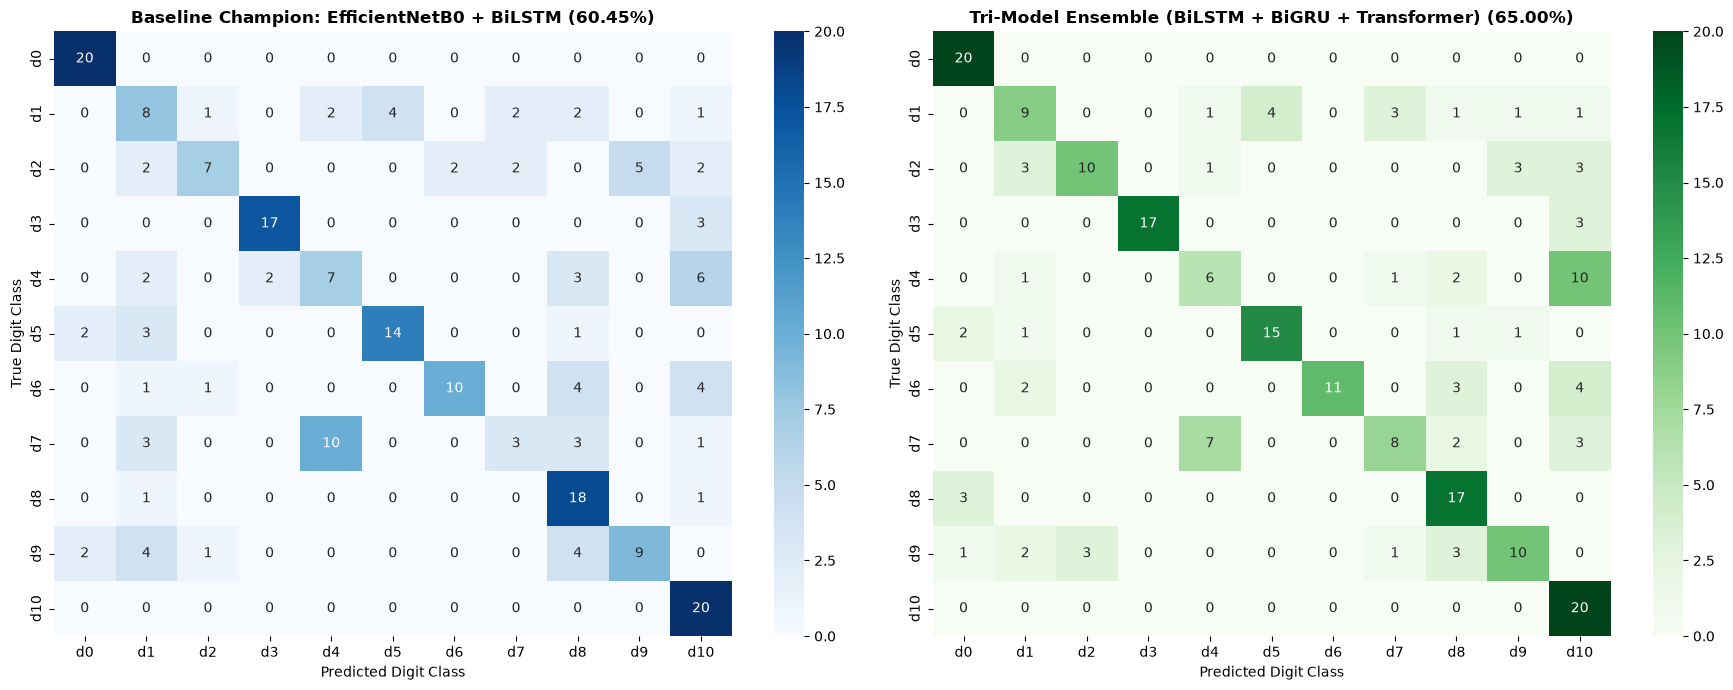

Ensemble confusion matrix saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/ensemble_bilstm_bigru_transformer_80_20/confusion_matrix_ensemble_comparison_80_20.png


In [17]:
# Section 17: Confusion Matrix Heatmaps (Single vs Ensemble)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Best Single Model (BiLSTM)
cm_lstm = confusion_matrix(y_val, preds_lstm)
sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=DIGIT_CLASSES,
    yticklabels=DIGIT_CLASSES,
    ax=axes[0],
    cbar=True
)
axes[0].set_title(f"Baseline Champion: EfficientNetB0 + BiLSTM ({acc_lstm*100:.2f}%)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Digit Class", fontsize=10)
axes[0].set_ylabel("True Digit Class", fontsize=10)

# 2. Tri-Model Optimal Ensemble
cm_ens = confusion_matrix(y_val, best_preds)
sns.heatmap(
    cm_ens,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=DIGIT_CLASSES,
    yticklabels=DIGIT_CLASSES,
    ax=axes[1],
    cbar=True
)
axes[1].set_title(f"Tri-Model Ensemble (BiLSTM + BiGRU + Transformer) ({best_acc*100:.2f}%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Digit Class", fontsize=10)
axes[1].set_ylabel("True Digit Class", fontsize=10)

plt.tight_layout()
cm_path = RESULTS_DIR / f"confusion_matrix_ensemble_comparison_{DATASET_MODE}.png"
plt.savefig(cm_path, dpi=200)
plt.show()
print(f"Ensemble confusion matrix saved to: {cm_path}")


## 18. Save Metrics Artifacts

In [18]:
# Section 18: Save Consolidated Ensemble Metrics
val_manifest["true_digit"] = [ID_TO_CLASS[y] for y in y_val]
val_manifest["pred_lstm"] = [ID_TO_CLASS[p] for p in preds_lstm]
val_manifest["pred_gru"] = [ID_TO_CLASS[p] for p in preds_gru]
val_manifest["pred_trans"] = [ID_TO_CLASS[p] for p in preds_trans]
val_manifest["pred_ensemble_uniform"] = [ID_TO_CLASS[p] for p in preds_uniform]
val_manifest["pred_ensemble_opt"] = [ID_TO_CLASS[p] for p in best_preds]
val_manifest["correct_opt"] = (val_manifest["digit_id"] == best_preds)

predictions_csv = RESULTS_DIR / f"validation_ensemble_predictions_{DATASET_MODE}.csv"
val_manifest[["speaker", "base_speaker", "digit", "digit_id", "pred_lstm", "pred_gru", "pred_trans", "pred_ensemble_opt", "correct_opt"]].to_csv(
    predictions_csv, index=False
)
print(f"Saved detailed predictions CSV to: {predictions_csv}")

metrics_data = {
    "experiment": "15_ensemble_bilstm_bigru_transformer",
    "dataset_mode": DATASET_MODE,
    "models_included": [
        "EfficientNetB0_BiLSTM_AttentionPooling",
        "EfficientNetB0_BiGRU_AttentionPooling",
        "EfficientNetB0_Transformer_4Block"
    ],
    "weights_paths": {
        "bilstm": str(WEIGHTS_LSTM_PATH),
        "bigru": str(WEIGHTS_GRU_PATH),
        "transformer": str(WEIGHTS_TRANS_PATH)
    },
    "individual_accuracies": {
        "bilstm": float(acc_lstm),
        "bigru": float(acc_gru),
        "transformer": float(acc_trans)
    },
    "ensemble_results": {
        "uniform": {
            "weights": [1/3, 1/3, 1/3],
            "accuracy": float(acc_uniform),
            "macro_f1": float(f1_uniform)
        },
        "optimal_weighted": {
            "weights": [float(w) for w in best_weights],
            "accuracy": float(best_acc),
            "macro_f1": float(best_f1)
        },
        "delta_over_best_single": float(best_acc - max(acc_lstm, acc_gru))
    },
    "num_validation_samples": int(len(y_val)),
    "num_validation_speakers": len(base_val_speakers)
}

metrics_json_path = RESULTS_DIR / f"metrics_ensemble_{DATASET_MODE}.json"
with open(metrics_json_path, "w") as f:
    json.dump(metrics_data, f, indent=2)
print(f"Saved metrics JSON to: {metrics_json_path}")


Saved detailed predictions CSV to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/ensemble_bilstm_bigru_transformer_80_20/validation_ensemble_predictions_80_20.csv
Saved metrics JSON to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/ensemble_bilstm_bigru_transformer_80_20/metrics_ensemble_80_20.json


## 19. Final Ensemble Summary

In [19]:
# Section 19: Final Printout
print("=" * 80)
print(f"FINAL ENSEMBLE SUMMARY [{DATASET_MODE}]")
print("=" * 80)
print(f"Best Single Model (BiLSTM)      : {acc_lstm * 100:.2f}%")
print(f"Co-Champion Model (BiGRU)       : {acc_gru * 100:.2f}%")
print(f"Complementary Model (Transformer): {acc_trans * 100:.2f}%")
print("-" * 80)
print(f"Uniform Ensemble (1/3 each)     : {acc_uniform * 100:.2f}%")
print(f"Optimal Weighted Ensemble       : {best_acc * 100:.2f}%  (weights: {best_weights})")
print(f"Net Ensemble Accuracy Gain       : {(best_acc - max(acc_lstm, acc_gru)) * 100:+.2f}%")
print("=" * 80)


FINAL ENSEMBLE SUMMARY [80_20]
Best Single Model (BiLSTM)      : 60.45%
Co-Champion Model (BiGRU)       : 60.00%
Complementary Model (Transformer): 52.73%
--------------------------------------------------------------------------------
Uniform Ensemble (1/3 each)     : 64.09%
Optimal Weighted Ensemble       : 65.00%  (weights: (np.float64(0.30000000000000004), np.float64(0.35), np.float64(0.35)))
Net Ensemble Accuracy Gain       : +4.55%
